# Case Study 2: Diabetes Readmission
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater

## Introduction

This case study uses the UCI Diabetes 130-US Hospitals dataset, which contains 10 years of clinical care records (1999–2008) across 130 US hospitals. Each row represents a single inpatient diabetic encounter. The target variable is `readmitted`, with three categories: `NO` (no readmission), `>30` (readmitted after 30 days), and `<30` (readmitted within 30 days). We build a multiclass logistic regression classifier to predict all three categories and identify the top variables driving readmission.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Suppress the PerformanceWarning raised by the diagnosis encoding loop below:
#   PerformanceWarning: DataFrame is highly fragmented. This is usually the result
#   of calling frame.insert many times, which has poor performance.
# Expected: the loop adds ~916 diagcode_* columns one at a time. The data.copy()
# call immediately after defragments the frame, which is exactly what pandas recommends.
# import warnings
# warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

data = pd.read_csv("./dataset_diabetes/diabetic_data.csv")

## Missingness Check & Imputation

Missing values are encoded as `'?'` strings rather than `NaN`. The `weight` column (~97% missing) is dropped. `payer_code` (~40%) and `medical_specialty` (~49%) are too sparse to impute meaningfully and are filled with `'Unknown'`. `race` (~2%) is mode-imputed. The diagnosis columns (`diag_1`, `diag_2`, `diag_3`) will be one-hot encoded in the next section rather than imputed. `'?'` simply becomes its own indicator column.

In [2]:
missing = (data == '?').sum()
missing[missing > 0]

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64

In [3]:
data = data.drop(columns=['weight'])

data['race'] = data['race'].replace('?', np.nan).fillna(data['race'].replace('?', np.nan).mode()[0])

for col in ['payer_code', 'medical_specialty']:
    data[col] = data[col].replace('?', 'Unknown')

## Diagnosis Code Encoding

Following the professor's approach: build a union of all unique diagnosis codes across `diag_1`, `diag_2`, and `diag_3`, then create a binary indicator column for each code. A row gets a `1` in `diagcode_X` if any of its three diagnosis fields contains code X. This avoids treating the codes as ordinal values and captures comorbidities naturally.

In [4]:
data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [5]:
diag = ['diag_1','diag_2','diag_3']

In [6]:
data[diag]

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
...,...,...,...
101761,250.13,291,458
101762,560,276,787
101763,38,590,296
101764,996,285,998


In [7]:
pd.get_dummies(data['diag_1'])

,10,11,110,112,114,115,117,131,133,135,...,V55,V56,V57,V58,V60,V63,V66,V67,V70,V71
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101762,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101763,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101764,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
data[diag]

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
...,...,...,...
101761,250.13,291,458
101762,560,276,787
101763,38,590,296
101764,996,285,998


In [9]:
data['diag_1'].unique()

<ArrowStringArray>
['250.83',    '276',    '648',      '8',    '197',    '414',    '428',
    '398',    '434',  '250.7',
 ...
     '58',    '649',    '832',    '133',    '975',    '833',    '391',
    '690',     '10',    'V51']
Length: 717, dtype: str

In [10]:
data['diag_2'].unique()

<ArrowStringArray>
[     '?', '250.01',    '250', '250.43',    '157',    '411',    '492',
    '427',    '198',    '403',
 ...
    '460',    '942',    '364',     '66',   'E883',    '123',    '884',
    'V60',    '843',    '927']
Length: 749, dtype: str

In [11]:
data['diag_3'].unique()

<ArrowStringArray>
[   '?',  '255',  'V27',  '403',  '250',  'V45',   '38',  '486',  '996',
  '197',
 ...
  '876',  '230',   '57', 'E854',  '942',   '14',  '750',  '370',  '671',
  '971']
Length: 790, dtype: str

In [12]:
cats = list(data['diag_1'].unique())+list(data['diag_2'].unique())+list(data['diag_3'].unique())

In [13]:
len(cats)

2256

In [14]:
cats = list(set(cats))

In [15]:
cats = [str(i) for i in cats]

In [16]:
for diag in cats:
    col_name = "diagcode_" + diag
    data[col_name] = 0

/tmp/ipykernel_32752/3223156647.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col_name] = 0
/tmp/ipykernel_32752/3223156647.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col_name] = 0
/tmp/ipykernel_32752/3223156647.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col_na

In [17]:
data=data.copy()

In [18]:
data.loc[0,['diag_1','diag_2','diag_3']]

diag_1    250.83
diag_2         ?
diag_3         ?
Name: 0, dtype: str

In [19]:
for index, values in data.iterrows():
    for i in ['diag_1','diag_2','diag_3']:
        diag_code = values[i]
        cols = "diagcode_" + str(diag_code)
        data.loc[index,cols] = 1
    if index%1000==0:
        print(index)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000


In [20]:
data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,diagcode_604,diagcode_228,diagcode_882,diagcode_153,diagcode_V62,diagcode_590,diagcode_908,diagcode_E915,diagcode_152,diagcode_V25
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,...,0,0,0,0,0,0,0,0,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,0,0,0,0,0,0,0,0,0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,0,0,0,0,0,0,0,0,0,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,0,0,0,0,0,0,0,0,0,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,0,0,0,0,0,0,0,0,0,0
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,0,0,0,0,0,1,0,0,0,0
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,0,0,0,0,0,0,0,0,0,0


In [21]:
data.loc[2321,['diag_1','diag_2','diag_3']]

diag_1      3
diag_2    276
diag_3    276
Name: 2321, dtype: str

In [22]:
data['diag_3']=data['diag_3'].astype(str)

In [23]:
data['diag_3'].dtype

<StringDtype(na_value=nan)>

## Feature Engineering & Encoding

We drop the ID columns, the original diagnosis columns (now encoded as `diagcode_*`), and two zero-variance drug columns (`examide`, `citoglipton`). Binary string columns are mapped directly to 0/1. All remaining categoricals are one-hot encoded with `get_dummies`. The target is label-encoded: sklearn assigns labels alphabetically, so `<30=0`, `>30=1`, `NO=2`.

In [24]:
data = data.drop(columns=['encounter_id', 'patient_nbr', 'diag_1', 'diag_2', 'diag_3', 'examide', 'citoglipton'])

data['change'] = (data['change'] == 'Ch').astype(int)
data['diabetesMed'] = (data['diabetesMed'] == 'Yes').astype(int)

le = LabelEncoder()
y = le.fit_transform(data['readmitted'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

data = data.drop(columns=['readmitted'])
data = pd.get_dummies(data)

{'<30': np.int64(0), '>30': np.int64(1), 'NO': np.int64(2)}


## Class Distribution

The target is imbalanced: `NO` accounts for ~54% of encounters, `>30` ~35%, and `<30` ~11%. Early readmission (`<30`) is the smallest and clinically most important class. This imbalance will be reflected in per-class precision and recall when we evaluate the model.

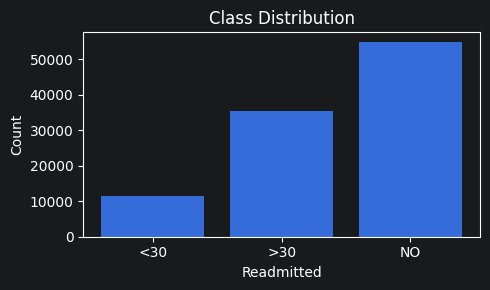

In [25]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(le.classes_, np.bincount(y))
ax.set_xlabel('Readmitted')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

## Logistic Regression

We do an 80/20 train/test split and fit `StandardScaler` on the training data only, then transform both sets. `LogisticRegression` with `lbfgs` handles multiclass natively without needing one-vs-rest. Default `max_iter=100` will likely not converge with ~1,000 features, so we set it to 1000. Given the class imbalance, expect strong performance on `NO` and weak recall on `<30`.

In [26]:
X = data.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

         <30       0.34      0.02      0.04      2285
         >30       0.49      0.33      0.40      7117
          NO       0.60      0.84      0.70     10952

    accuracy                           0.57     20354
   macro avg       0.48      0.40      0.38     20354
weighted avg       0.53      0.57      0.52     20354



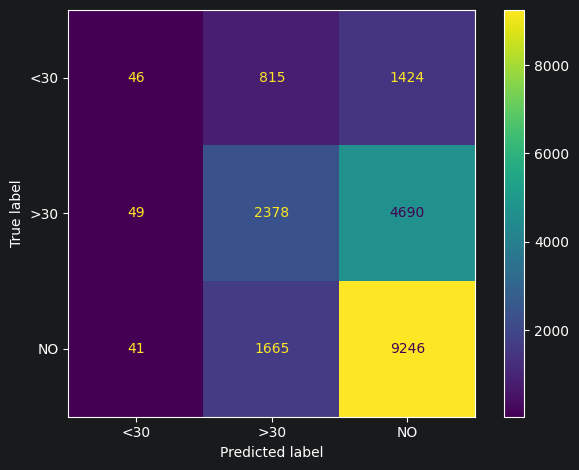

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)
plt.tight_layout()
plt.show()

The model leans heavily on `NO` with recall of 0.84 there but nearly zero on `<30` (0.02), meaning it almost never predicts early readmission. Only 46 of 2,285 actual `<30` cases were caught. The 0.57 accuracy is barely better than a naive baseline of ~0.54 achieved by just predicting `NO` every time. `>30` is middling at 0.33 recall. This is a direct consequence of the class imbalance: the model learns that guessing `NO` is usually right and rarely takes a risk on the minority class.

## Variable Importance

`model.coef_` returns a matrix of shape `(3 classes, n_features)`. For each class, we take the 5 features with the largest absolute coefficient values. A large positive coefficient pushes the model toward predicting that class; a large negative coefficient pushes away from it.

In [30]:
feature_names = data.columns.tolist()

for i, cls in enumerate(le.classes_):
    coefs = pd.Series(model.coef_[i], index=feature_names)
    top5 = coefs.abs().nlargest(5)
    print(f"Top 5 features for class '{cls}':", )
    print(coefs[top5.index].round(3).to_string())

Top 5 features for class '<30':
number_inpatient                0.230
diagcode_462                   -0.088
diagcode_527                   -0.088
medical_specialty_Gynecology   -0.081
diagcode_923                   -0.077
Top 5 features for class '>30':
discharge_disposition_id   -0.096
number_inpatient            0.076
diagcode_865               -0.062
number_outpatient           0.058
diagcode_524               -0.058
Top 5 features for class 'NO':
number_inpatient   -0.306
number_emergency   -0.132
diabetesMed        -0.081
number_diagnoses   -0.069
diagcode_428       -0.067


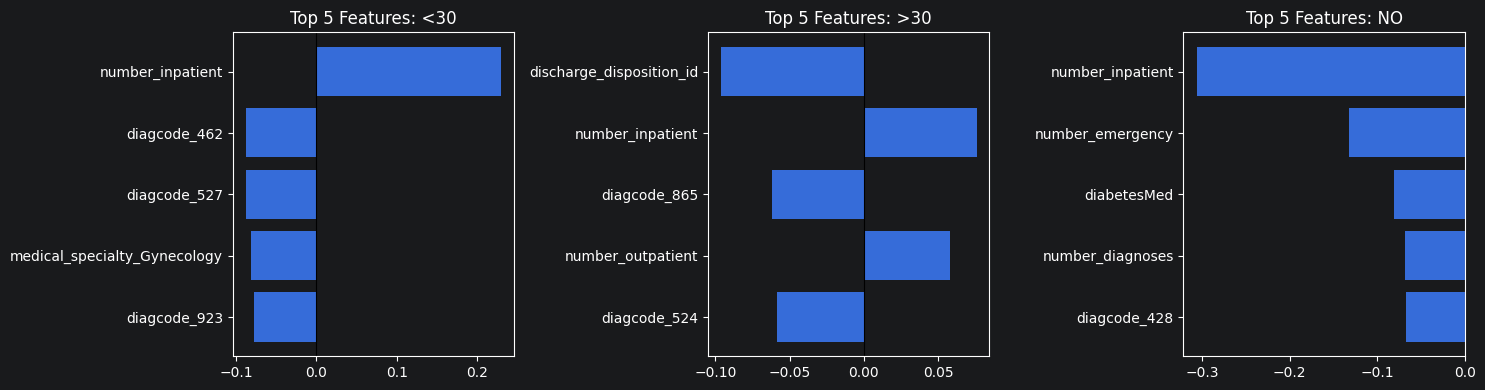

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
    coefs = pd.Series(model.coef_[i], index=feature_names)
    top5 = coefs.abs().nlargest(5)
    ax.barh(top5.index, coefs[top5.index])
    ax.set_title(f"Top 5 Features: {cls}")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

**`<30`:** `number_inpatient` is the strongest positive predictor of early readmission; patients with more prior inpatient stays are already high utilizers and more likely to bounce back quickly.

**`>30`:** `discharge_disposition_id` is the top negative predictor, suggesting where a patient is discharged to (home, skilled nursing, etc.) influences whether they return after 30 days. `number_outpatient` is a positive predictor, consistent with patients who have ongoing conditions driving later readmission.

**`NO`:** `number_inpatient` is the dominant negative predictor, consistent with its positive role in the readmission classes. `number_emergency`, `number_diagnoses`, and `diagcode_428` (heart failure) all push away from `NO`, reflecting that patients with higher utilization and more serious comorbidities are less likely to avoid readmission entirely.

## Conclusion

The logistic regression model achieves modest overall accuracy (0.57) but struggles with early readmission (`<30`), the most clinically important class, due to severe class imbalance. Prior utilization, particularly `number_inpatient`, is the most consistent predictor of readmission across all three classes.

---

### Model Performance

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| `<30` | 0.34 | 0.02 | 0.04 | 2,285 |
| `>30` | 0.49 | 0.33 | 0.40 | 7,117 |
| `NO` | 0.60 | 0.84 | 0.70 | 10,952 |
| accuracy | | | 0.57 | 20,354 |
| macro avg | 0.48 | 0.40 | 0.38 | 20,354 |
| weighted avg | 0.53 | 0.57 | 0.52 | 20,354 |

### Top 5 Features by Class

**`<30`**

| Feature | Coefficient |
|---|---|
| `number_inpatient` | 0.230 |
| `diagcode_462` | -0.088 |
| `diagcode_527` | -0.088 |
| `medical_specialty_Gynecology` | -0.081 |
| `diagcode_923` | -0.077 |

**`>30`**

| Feature | Coefficient |
|---|---|
| `discharge_disposition_id` | -0.096 |
| `number_inpatient` | 0.076 |
| `diagcode_865` | -0.062 |
| `number_outpatient` | 0.058 |
| `diagcode_524` | -0.058 |

**`NO`**

| Feature | Coefficient |
|---|---|
| `number_inpatient` | -0.306 |
| `number_emergency` | -0.132 |
| `diabetesMed` | -0.081 |
| `number_diagnoses` | -0.069 |
| `diagcode_428` | -0.067 |
